# データ取得

In [42]:

import os
import json


# ================================　タスクセット　　================================

# ディレクトリパス
task_sets_path = "C:/Users/Tenma/Desktop/Keio/InteractiveSmartHome/InteractiveSmartHome/InteractiveSmartHome/Assets/EXPERIMENT/ArrangeData"

# 対象ファイル
file_names = ["PreTaskArrangementA.json", "PreTaskArrangementB.json", 
              "PreTaskArrangementC.json", "PreTaskArrangementD.json"]

# すべてのタスクを格納するリスト
all_task_sets = []

# 各ファイルを読み込んで統合
for file_name in file_names:
    file_path = os.path.join(task_sets_path, file_name)
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)
        all_task_sets.extend(data)  # 各ファイルがリスト形式であることを前提

# 確認（最初の1件だけ表示）
print(all_task_sets[0])

task_id_to_info = {}

for task in all_task_sets:
    task_id_to_info[task["device_arrange_id"]] = {
        "name": task["device_arrange_name"],
        "devices": task["devices"]
    }





# ================================　処理結果　　================================

import os
import json
from collections import defaultdict

# フォルダパス
result_dir = "C:/Users/Tenma/Desktop/Keio/InteractiveSmartHome/InteractiveSmartHome/LLMServer/ExperimentData/RESULTS/SystemEvaluation"

# 除外する task_id のリスト（必要に応じて追加）
exclude_task_ids = {
    "b0e9f035-c92f-4dc6-bd0a-a10b2941f902"  # ← 外れ値
    # 他にも追加可能: "another-task-id", ...
}

# 結果を格納するネスト辞書
evaluation_results = defaultdict(dict)

# ファイル読み込みループ
for filename in os.listdir(result_dir):
    if filename.endswith(".json"):
        filepath = os.path.join(result_dir, filename)
        # ファイル名から model名 と 評価方式を抽出
        parts = filename.replace("SystemEvaluation_", "").replace(".json", "").split("_")
        model = parts[0]
        eval_type = parts[1] if len(parts) > 1 else "unknown"

        # JSONロード＋task_id除外
        with open(filepath, "r", encoding="utf-8") as f:
            data = json.load(f)

            # データがリスト形式なら除外フィルターをかける
            if isinstance(data, list):
                filtered_data = [entry for entry in data if entry.get("task_id") not in exclude_task_ids]
                evaluation_results[model][eval_type] = filtered_data
            else:
                evaluation_results[model][eval_type] = data  # 念のため辞書型も対応

# 利用例
print(evaluation_results["gpt-4o"]["pointing"][0])  # 最初のタスクの出力を確認



{'device_arrange_id': '2369c5c0-c4bb-4308-a9cd-05a64a69f91a', 'device_arrange_name': '手前三つ青奥三つ赤', 'device_arrange_type': [], 'devices': [{'deviceName': 'Ceiling Light 6', 'colorName': 'Blue', 'deviceId': '58126407-cde0-4d62-a13d-1a24bf8ea5f3'}, {'deviceName': 'Ceiling Light 2', 'colorName': 'Red', 'deviceId': '781e6091-cec9-4c26-9f3e-4d48d6d7570a'}, {'deviceName': 'Ceiling Light 4', 'colorName': 'Red', 'deviceId': '6ac4ec9f-0326-4619-b79a-ecbbe5459d23'}, {'deviceName': 'Ceiling Light 3', 'colorName': 'Red', 'deviceId': '6f1c35e2-1ca1-4f43-93cf-755d9479025b'}, {'deviceName': 'Ceiling Light 8', 'colorName': 'Blue', 'deviceId': '74a6f0f8-be5d-479e-9e08-91d6bd599916'}, {'deviceName': 'Ceiling Light 7', 'colorName': 'Blue', 'deviceId': 'e9a21485-0eb4-40ad-a985-cef8bc98d190'}]}
{'user_prompt': 'この二つをオレンジにして ', 'pointed_devices': [{'id': '3da605b5-b12f-4fe8-9108-f4a6648efb3b', 'name': 'Ceiling Light 11', 'position': {'x': 0.813812137, 'y': 2.25890779, 'z': -0.174801424}, 'distance_from_user':

In [112]:
a = evaluation_results["gpt-4o"]["system"][0]
a["agent_output"]

{'devices': [{'id': '9cbd6e9a-4f7b-41e8-b1dc-464d631dfd7f',
   'state': True,
   'intensity': 100,
   'color': {'r': 255, 'g': 165, 'b': 0}},
  {'id': '6e82a90c-d3bb-4e45-b221-ebe21c524b04',
   'state': True,
   'intensity': 100,
   'color': {'r': 255, 'g': 165, 'b': 0}}],
 'response': '俺の後ろの天井の右2つのライトをオレンジにしました。',
 'reasoning': 'ユーザーの指示に基づき、『後ろ』はz軸で負の方向を示し、『天井の右』はx軸におけるプラス方向を示します。デバイスの位置から、後ろの天井に2つ並んでいるデバイスを特定し、オレンジ色に設定しました。'}

# 時間評価結果

In [84]:
import pandas as pd
def summarize_metrics(task_info: dict, evaluation_results: dict) -> pd.DataFrame:
    rows = []

    for model, eval_dict in evaluation_results.items():
        for eval_type, results in eval_dict.items():
            for record in results:
                task_id = record.get("task_id")

                # ✨ system_total_time_sec は record の最上位に存在
                system_time = record.get("system_total_time_sec")
                cost_usd = record.get("filterAgent", {}).get("metrics", {}).get("cost_usd") \
                    if eval_type == "system" else \
                    record.get("spatialAgent", {}).get("metrics", {}).get("cost_usd") \
                    if eval_type == "spatial" else \
                    record.get("metrics", {}).get("cost_usd")

                rows.append({
                    "model": model,
                    "eval_type": eval_type,
                    "system_time_sec": system_time,
                    "cost_usd": cost_usd,
                })

    df = pd.DataFrame(rows)

    df_summary = df.groupby(["model", "eval_type"]).agg({
        "system_time_sec": ["min", "max", "mean"],
        "cost_usd": ["min", "max", "mean"]
    }).reset_index()

    df_summary.columns = [
        "model", "eval_type",
        "system_time_min", "system_time_max", "system_time_mean",
        "cost_min", "cost_max", "cost_mean"
    ]

    return df_summary


In [85]:
time_data = summarize_metrics(task_id_to_info, evaluation_results)
time_data

,model,eval_type,system_time_min,system_time_max,system_time_mean,cost_min,cost_max,cost_mean
0,gpt-4.1,pointing,1.694347,14.631763,5.462305,0.007083,0.028725,0.011144
1,gpt-4.1,spatial,4.371963,36.416097,8.872848,0.015013,0.065310,0.019923
2,gpt-4.1,system,5.865902,37.057552,10.605073,0.004270,0.027665,0.005442
3,gpt-4.1-nano,pointing,1.588022,13.121582,4.678132,0.006940,0.025575,0.010356
4,gpt-4.1-nano,spatial,3.915362,38.341233,8.963837,0.009055,0.070588,0.019984
5,gpt-4.1-nano,system,5.458564,31.495432,10.127948,0.004225,0.020555,0.004958
6,gpt-4o,pointing,1.366126,13.251957,4.652608,0.006960,0.021423,0.010253
7,gpt-4o,spatial,4.212652,43.360173,9.023715,0.015418,0.069803,0.019965
8,gpt-4o,system,5.851797,26.282245,10.008119,0.004233,0.004683,0.004422
9,gpt-4o-mini,pointing,1.577704,14.860325,5.737562,0.006910,0.028480,0.010752


In [103]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# ✨ 新：summarize_metrics の出力に依存する箱ひげ図関数（実は箱ひげじゃないがmean棒グラフ用）
def plot_boxplot_from_summarized_metrics(summary_df: pd.DataFrame):
    """
    summarize_metrics() の出力を使って、system_time_mean を箱ひげ図“風”に棒グラフで描く。
    """
    plt.figure(figsize=(10, 6))
    sns.barplot(data=summary_df, x="eval_type", y="system_time_mean", hue="model")
    plt.title("System Time Mean per Model and Eval Type (Summarized)")
    plt.ylabel("Mean System Time (sec)")
    plt.xlabel("Evaluation Type")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def collect_raw_system_times(evaluation_results: dict) -> pd.DataFrame:
    rows = []
    for model, eval_dict in evaluation_results.items():
        for eval_type, results in eval_dict.items():
            for record in results:
                system_time = record.get("system_total_time_sec")
                if system_time is not None:
                    rows.append({
                        "model": model,
                        "eval_type": eval_type,
                        "system_time_sec": system_time
                    })
    return pd.DataFrame(rows)
def remove_outliers_iqr_grouped(df: pd.DataFrame, column: str) -> pd.DataFrame:
    result_df = pd.DataFrame()
    for (model, eval_type), group in df.groupby(["model", "eval_type"]):
        clean_group = group[[column]].dropna()
        if clean_group.empty or len(clean_group) < 4:
            result_df = pd.concat([result_df, group])
            continue
        Q1 = clean_group[column].quantile(0.25)
        Q3 = clean_group[column].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        filtered = group[(group[column] >= lower) & (group[column] <= upper)]
        result_df = pd.concat([result_df, filtered])
    return result_df.reset_index(drop=True)
def plot_system_time_boxplot(df: pd.DataFrame):
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x="eval_type", y="system_time_sec", hue="model")
    plt.title("System Time Distribution per Model and Eval Type")
    plt.ylabel("System Time (sec)")
    plt.xlabel("Evaluation Type")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_summary_barplot(summary_df: pd.DataFrame):
    plt.figure(figsize=(10, 6))
    sns.barplot(data=summary_df, x="eval_type", y="system_time_mean", hue="model")
    plt.title("System Time Mean per Model and Eval Type")
    plt.ylabel("Mean System Time (sec)")
    plt.xlabel("Evaluation Type")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


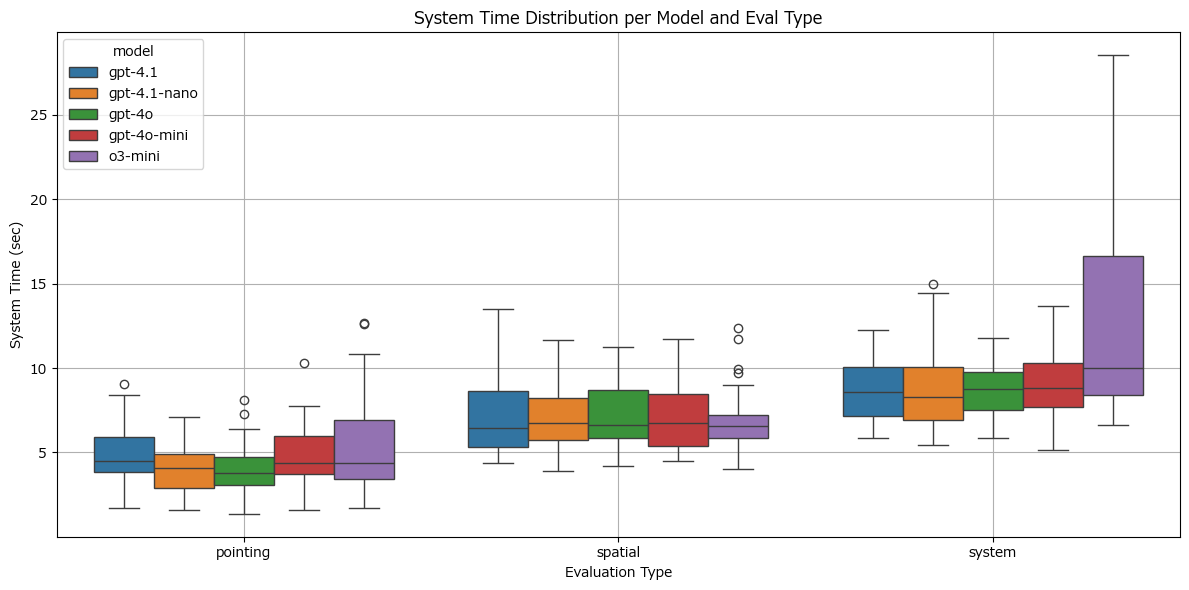

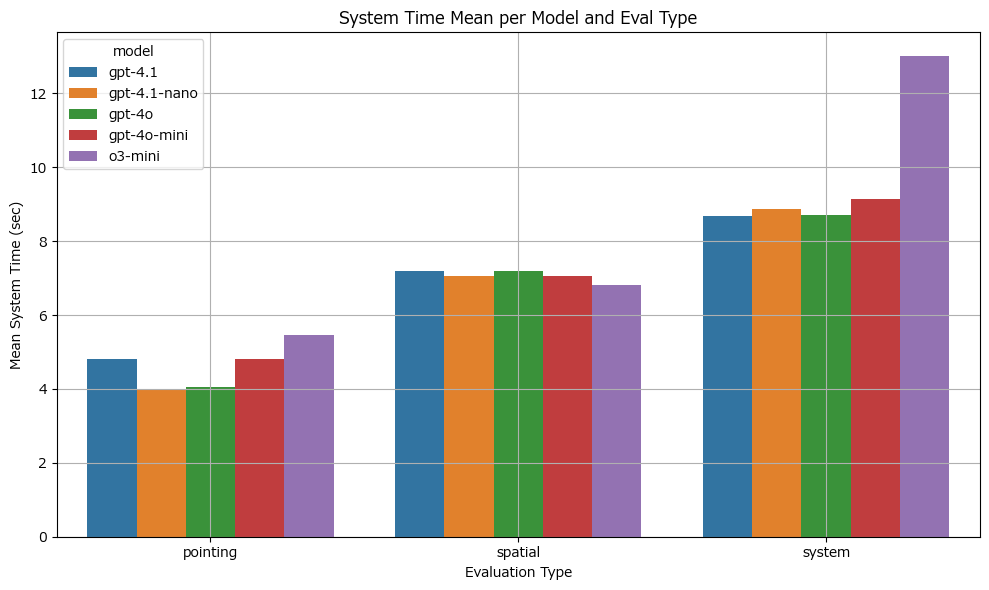

In [104]:
# 生データ取得（箱ひげ図用）
df_raw = collect_raw_system_times(evaluation_results)

# 外れ値除去
df_clean = remove_outliers_iqr_grouped(df_raw, "system_time_sec")

# 箱ひげ図！
plot_system_time_boxplot(df_clean)

# 要約統計も取得（平均バー用）
summary = df_clean.groupby(["model", "eval_type"])["system_time_sec"].agg(["min", "max", "mean"]).reset_index()
summary.rename(columns={"mean": "system_time_mean"}, inplace=True)

# バーグラフ！
plot_summary_barplot(summary)


# 性能評価

In [115]:
import pandas as pd

def compute_metrics_per_record(evaluation_results, task_id_to_info):
    rows = []

    for model, eval_types in evaluation_results.items():
        for eval_type, records in eval_types.items():
            for record in records:
                task_id = record.get("task_id")
                if task_id not in task_id_to_info:
                    continue

                # Ground truth device IDs
                ground_truth_ids = {d["deviceId"] for d in task_id_to_info[task_id]["devices"]}

                # Predicted device IDs
                if eval_type == "pointing":
                    predicted_ids = {d["id"] for d in record.get("metrics", {}).get("devices", [])}
                elif eval_type == "system":
                    predicted_ids = {d["id"] for d in record.get("filterAgent", {}).get("devices", [])}
                else:
                    predicted_ids = {d["id"] for d in record.get("agent_output", {}).get("devices", [])}

                # Accuracy（完全一致）
                is_exact_match = ground_truth_ids == predicted_ids

                # Precision / Recall / F1
                tp = len(ground_truth_ids & predicted_ids)
                fp = len(predicted_ids - ground_truth_ids)
                fn = len(ground_truth_ids - predicted_ids)

                precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
                recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
                f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

                rows.append({
                    "model": model,
                    "eval_type": eval_type,
                    "task_id": task_id,
                    "accuracy": 1.0 if is_exact_match else 0.0,
                    "precision": precision,
                    "recall": recall,
                    "f1_score": f1,
                    "gt_count": len(ground_truth_ids),
                    "pred_count": len(predicted_ids)
                })

    return pd.DataFrame(rows)


In [116]:
result = compute_metrics_per_record(evaluation_results, task_id_to_info)
result

,model,eval_type,task_id,accuracy,precision,recall,f1_score,gt_count,pred_count
0,gpt-4.1-nano,pointing,25c3ccdb-26c7-4109-bcfe-730434f9caa9,0.0,0.000000,0.000000,0.000000,2,0
1,gpt-4.1-nano,pointing,fcee09b7-efa4-4e87-956e-553ee7bb3648,0.0,0.000000,0.000000,0.000000,2,0
2,gpt-4.1-nano,pointing,81c1a60b-c8ac-4a16-b831-1df68863e61e,0.0,0.000000,0.000000,0.000000,3,0
3,gpt-4.1-nano,pointing,04f5e376-2845-485a-8cb1-c38e3858ff8a,0.0,0.000000,0.000000,0.000000,4,0
4,gpt-4.1-nano,pointing,bee10050-f98c-456a-a684-4435ee88ef00,0.0,0.000000,0.000000,0.000000,3,0
...,...,...,...,...,...,...,...,...,...
675,o3-mini,system,cd873fbb-fcc1-43bd-8f04-bb3b2d716af4,0.0,0.500000,0.833333,0.625000,6,10
676,o3-mini,system,ff4748e2-cd97-45bb-bf2c-e5c9c33f78ac,0.0,0.750000,1.000000,0.857143,3,4
677,o3-mini,system,4f145d76-f69f-4547-90a7-56281733ca5b,0.0,0.666667,1.000000,0.800000,2,3
678,o3-mini,system,137e922c-0877-46af-a797-5a32df2edf5d,0.0,0.333333,1.000000,0.500000,3,9
